In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [ ]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'

adata = sc.read_h5ad(adata_path)

adata.obs['cell_type'] = pd.read_csv('../../3_figure_FFPE/output/GBM_cell_type_labels.txt', sep='\t', index_col=0).loc[adata.obs_names, 'cell_type']
adata.obs['tumor_normal_infercnv'] = pd.read_csv('../../3_figure_FFPE/output/tumor_normal_labels_infercnv.txt', sep='\t', index_col=0).loc[adata.obs_names, 'infercnv']

variants = ['EGFR VIII', 'CARD11 c.2149G>A', 'AXL c.1103G>A', 'EGFR c.685A>T', 'EGFR c.1889_1894delinsTAGGAT']


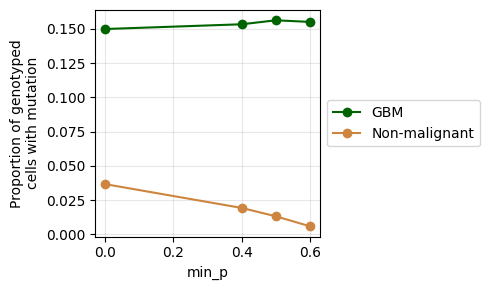

In [ ]:
results = []

for min_p in [0, 0.4, 0.5, 0.6]:
    gf_utils.assign_genotypes(adata, min_counts=0, min_p=min_p)
    adata.obsm['genotype_call'] = adata.obsm['genotype_call'][variants].copy()

    normal_calls = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'normal']
    tumor_calls = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'tumor']

    n_normal_mutated = (normal_calls.isin(['mutated', 'heterozygous']).sum(axis=1) > 0).sum()
    n_normal_total = (normal_calls.isin(['mutated', 'heterozygous','wt']).sum(axis=1) > 0).sum()
    n_tumor_mutated = (tumor_calls.isin(['mutated', 'heterozygous']).sum(axis=1) > 0).sum()
    n_tumor_total = (tumor_calls.isin(['mutated', 'heterozygous','wt']).sum(axis=1) > 0).sum()

    TPR = n_tumor_mutated / (n_tumor_total)
    FPR = n_normal_mutated / (n_normal_total)
    results.append({
        'min_p': min_p, 'FPR': FPR, 'TPR': TPR,
        'n_normal': n_normal_total,
        'n_tumor': n_tumor_total,
    })

fpr_df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(fpr_df['min_p'], fpr_df['TPR'], marker='o', label='GBM', color = 'darkgreen')
ax1.plot(fpr_df['min_p'], fpr_df['FPR'], marker='o', label='Non-malignant', color= 'peru')
ax1.set_ylabel('Proportion of genotyped\ncells with mutation')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax1.set_xlabel('min_p')
ax1.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../plots/mutated_prop_vs_min_p.pdf')

In [4]:
results

[{'min_p': 0,
  'FPR': 0.03666245259165613,
  'TPR': 0.14978791092258747,
  'n_normal': 791,
  'n_tumor': 7544},
 {'min_p': 0.4,
  'FPR': 0.019305019305019305,
  'TPR': 0.1532440162577149,
  'n_normal': 518,
  'n_tumor': 6643},
 {'min_p': 0.5,
  'FPR': 0.013227513227513227,
  'TPR': 0.1561409076483656,
  'n_normal': 378,
  'n_tumor': 6302},
 {'min_p': 0.6,
  'FPR': 0.005934718100890208,
  'TPR': 0.15497076023391812,
  'n_normal': 337,
  'n_tumor': 6156}]